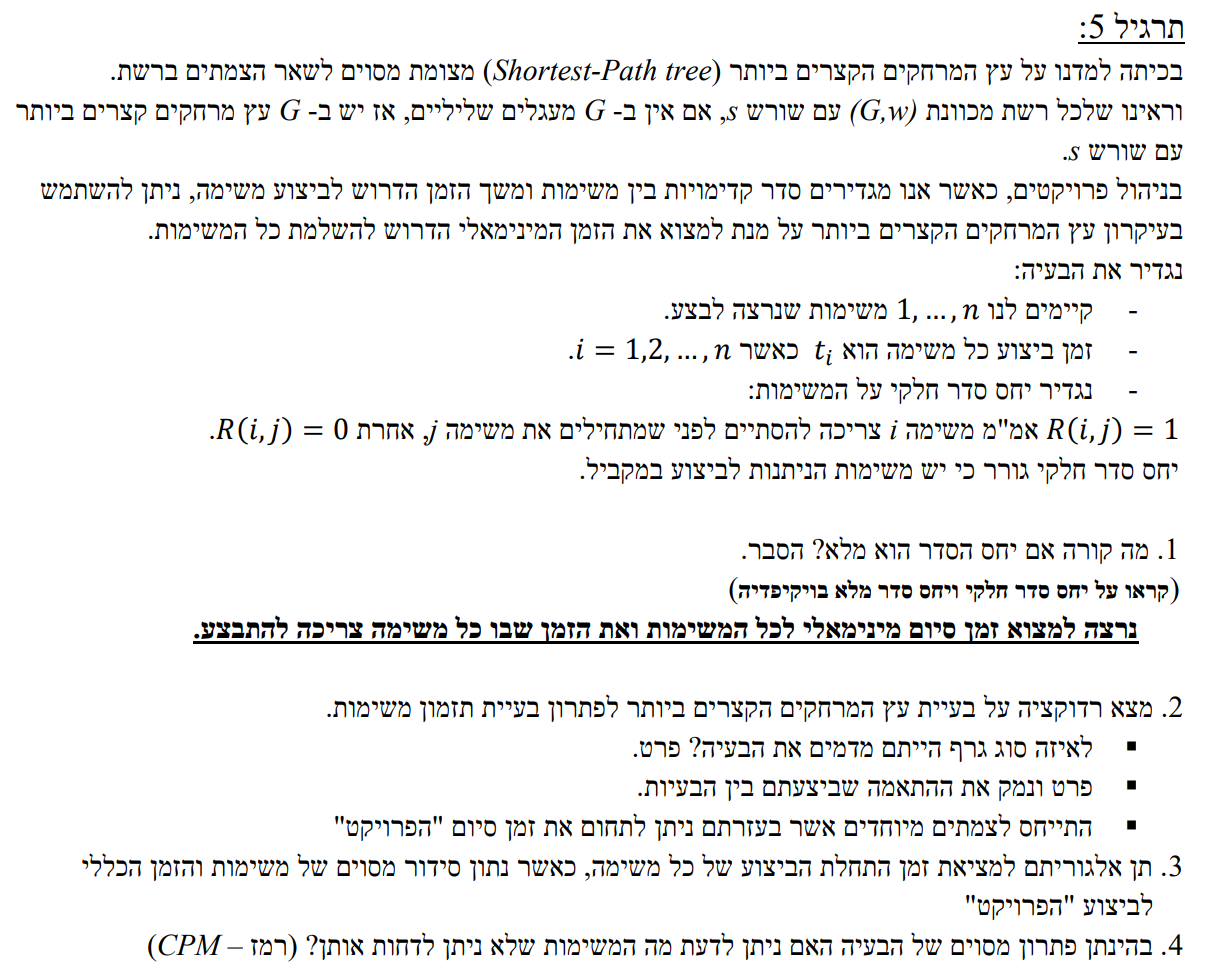

In [98]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

In [107]:
def generate_random_project_dag(num_tasks, edge_probability, seed=None):
    """
    Generates a random valid DAG and a corresponding list of execution times.
    
    :param num_tasks: Total number of tasks (nodes) N. Nodes will be 1...N.
    :param edge_probability: Float between 0.0 and 1.0.
    :param seed: Integer seed for reproducible random generation.
    :return: A tuple (G, T) where G is the networkx DiGraph, 
            and T is a list where T[v] is the execution time of task v.
    """
    if seed is not None:
        random.seed(seed)
        
    G = nx.DiGraph()
    
    # Initialize T with size N + 1. 
    # T[0] is a dummy value so that 1-based indexing aligns perfectly with the nodes.
    T = [0] * num_tasks
    
    for i in range(1, num_tasks):
        execution_time = random.randint(1, 10) 
        
        # Add to graph
        G.add_node(i, time=execution_time)
        
        # Store in our dedicated array
        T[i] = execution_time
        
    # Generate random dependencies (guaranteed no cycles by only connecting i -> j if i < j)
    for i in range(num_tasks):
        for j in range(i + 1, num_tasks):
            if random.random() < edge_probability:
                G.add_edge(i, j)
                
    return G, T

# --- How to use it ---

N = 8
seed=5
p = 0.3

G,T = generate_random_project_dag(num_tasks=N, edge_probability=p, seed=42)

print(f"Is this a valid DAG? {nx.is_directed_acyclic_graph(G)}")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of dependencies (edges): {G.number_of_edges()}")

print("\nNode execution times:")
print(G.nodes(data=True))

print("\nRandomized Dependencies:")
print(G.edges())

Is this a valid DAG? True
Number of nodes: 8
Number of dependencies (edges): 10

Node execution times:
[(1, {'time': 2}), (2, {'time': 1}), (3, {'time': 5}), (4, {'time': 4}), (5, {'time': 4}), (6, {'time': 3}), (7, {'time': 2}), (0, {})]

Randomized Dependencies:
[(1, 2), (1, 3), (1, 6), (2, 4), (3, 4), (3, 7), (4, 5), (0, 3), (0, 5), (0, 6)]


T: [0, 2, 1, 5, 4, 4, 3, 2]


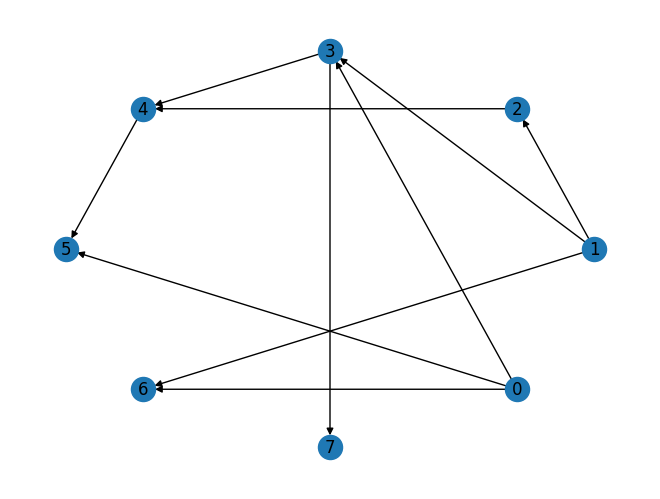

In [108]:
layout = nx.layout.circular_layout(G)
print("T:", T)
nx.draw(G, pos=layout, with_labels=True)
plt.show()

In [121]:
def top_sort_time(G,T):
    # Inintialize S and F
    V = G.nodes()
    
    N = len(V)
    S = [0] * N 
    F = [0] * N
    
    # Initialize S and F for roots
    for v in V:
        if G.in_degree(v) == 0:
            S[v] = 0
            F[v] = T[v]
        else:
            S[v] = None
            F[v] = None
    
    # print("S:", S)
    # print("F:", F)
    
    U = [v for v in V]
    print("U:", U)
    # looping as long as there are vertices in U
    while len(U):
        # getting the vertex with the smallest in-degree in U
        u = min(U, key=lambda x: G.in_degree(x))
        
        print("u:",u)
        
        # setting the start time of u as the maximum finish time of its predecessors
        S[u] = max([F[pred] for pred in G.predecessors(u)], default=0)
        F[u] = S[u] + T[u]
        
        # removing u from U
        U.remove(u)

    return S, F


S,F = top_sort_time(G,T)

print("S:", S)
print("F:", F) 

U: [1, 2, 3, 4, 5, 6, 7, 0]
u: 1
u: 0
u: 2
u: 7


TypeError: unsupported operand type(s) for +: 'NoneType' and 'int'